<a id="phase42"></a>

# Détection Précoce des Troubles Psychiatriques 🧠

## Objectif
Construire un pipeline de préparation de données robuste pour un système de triage textuel **non diagnostique**, centré sur l’identification précoce de signaux linguistiques associés à plusieurs troubles psychiatriques.

## Portée clinique
Ce projet est conçu comme un **outil d’aide au repérage précoce**.  
Il **ne remplace pas** un diagnostic médical, une évaluation psychiatrique ou une décision clinique.

## Objectif de ce notebook
Ce notebook couvre uniquement :
- la configuration du projet
- le chargement du dataset brut
- le nettoyage prudent des textes
- la normalisation de la variable cible
- l’EDA descriptive principale
- l’audit de fuite lexicale
- la création de la version masquée `body_masked`
- la validation finale et l’export du dataset nettoyé

---

## Plan du notebook

### [Phase 0 — Configuration du projet](#phase0)
1. [Arborescence et chemins](#0-1)
2. [Imports et configuration globale](#0-2)

### [Phase 1 — Exploration descriptive et audit initial](#phase1)
1. [Chargement des données](#1-1)
2. [EDA globale](#1-2)
3. [Analyse linguistique](#1-3)
4. [Analyse psycholinguistique avancée](#1-4)
5. [Audit de fuite lexicale](#1-5)
6. [Signatures sémantiques](#1-6)
7. [Synthèse EDA](#1-7)

### [Phase 2 — Prétraitement et export](#phase2)
1. [Pipeline de nettoyage](#2-1)
2. [Normalisation de la cible](#2-2)
3. [Création de `body_masked`](#2-3)
4. [Validation du dataset final](#2-4)
5. [Export sécurisé](#2-5)

---

## Livrable principal
Le fichier exporté à la fin de ce notebook est :

`mental_health_detection_clean.csv`

<a id="phase0"></a>

# Phase 0 — Configuration du projet

<a id="0-1"></a>

## Arborescence et chemins du projet

L’objectif de cette section est de centraliser tous les chemins utilisés dans le projet afin de garantir une exécution reproductible, lisible et facile à maintenir.

In [1]:
import sys
from pathlib import Path

current = Path.cwd().resolve()

if current.name == "notebooks":
    PROJECT_ROOT = current.parent
elif (current / "src").exists():
    PROJECT_ROOT = current
else:
    PROJECT_ROOT = current

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config.paths import *

In [2]:
from pathlib import Path
import os

PROJECT_ROOT = Path(
    os.getenv(
        "PROJECT_ROOT",
        PROJECT_ROOT 
    )
)

DATA_DIR = PROJECT_ROOT / "data"
DATA_RAW_DIR = DATA_DIR / "raw"
DATA_CLEAN_DIR = DATA_DIR / "clean"

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"

EDA_TABLES_DIR = TABLES_DIR / "eda"
EDA_FIGURES_DIR = FIGURES_DIR / "eda"

RAW_DATA_PATH = DATA_RAW_DIR / "Mental Health Disorder Detection Dataset.csv"
CLEAN_DATA_PATH = DATA_CLEAN_DIR / "mental_health_detection_clean.csv"

for directory in [
    DATA_RAW_DIR,
    DATA_CLEAN_DIR,
    EDA_TABLES_DIR,
    EDA_FIGURES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

<a id="0-2"></a>

## Imports, constantes et configuration globale

Cette section centralise les bibliothèques, les constantes métier, les paramètres de reproductibilité et les fonctions d’affichage utilisées dans l’ensemble du notebook.

In [15]:
# Standard library
import html
import re
import string
import warnings
from collections import Counter
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud

# Notebook display
from IPython.display import Markdown, display

# Configuration
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Column names
TEXT_COL = "body"
TARGET_COL = "category"
MASKED_COL = "body_masked"

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.precision", 3)

PLOTLY_TEMPLATE = "plotly_white"

MEDICATION_TERMS = [
    "ritalin", "concerta", "vyvanse", "adderall", "strattera",
    "lithium", "lamotrigine", "lamictal", "depakote", "valproate",
    "lexapro", "zoloft", "prozac", "sertraline", "escitalopram", "fluoxetine",
    "xanax", "alprazolam", "valium", "diazepam", "ativan", "lorazepam",
    "clozapine", "clozaril", "risperidone", "risperdal", "olanzapine",
    "zyprexa", "quetiapine", "seroquel", "haldol"
]

DIAGNOSTIC_TERMS = [
    "adhd", "add", "asd", "autism", "autistic", "bpd", "borderline",
    "bipolar", "schizophrenia", "schizoaffective", "schizo",
    "depression", "depressed", "anxiety", "anxious"
]

FULL_LEAK_LIST = DIAGNOSTIC_TERMS + MEDICATION_TERMS


def style_clinical_report(
    styler,
    title=None,
    focus_classes=("Bipolar", "schizophrenia"),
    precision=3
):
    """
    Apply a consistent visual style to clinical summary tables.
    """
    focus_color = "rgba(255, 215, 0, 0.35)"
    header_blue = "#20639b"

    styler = styler.background_gradient(cmap="Blues")

    def highlight_row(row):
        if row.name in focus_classes:
            return [
                f"background-color: {focus_color}; color: black; font-weight: bold"
            ] * len(row)
        return [""] * len(row)

    styler = (
        styler
        .format(precision=precision)
        .apply(highlight_row, axis=1)
        .set_table_styles([
            {
                "selector": "th.col_heading",
                "props": [
                    ("background-color", header_blue),
                    ("color", "white"),
                    ("text-align", "center"),
                    ("font-weight", "bold"),
                    ("border", "1px solid #777")
                ]
            },
            {
                "selector": "th.row_heading",
                "props": [
                    ("background-color", header_blue),
                    ("color", "white"),
                    ("text-align", "left"),
                    ("padding", "8px 15px"),
                    ("border", "1px solid #777")
                ]
            },
            {
                "selector": "td",
                "props": [("border", "1px solid #777")]
            }
        ])
    )

    if title:
        styler = styler.set_caption(
            f"<div style='font-size:1.1em; padding:10px;'>📊 <b>{title}</b></div>"
        )

    return styler


print("✅ Imports and configuration completed")
print(f"RANDOM_STATE = {RANDOM_STATE}")
print(f"TEXT_COL = {TEXT_COL}")
print(f"TARGET_COL = {TARGET_COL}")
print(f"MASKED_COL = {MASKED_COL}")

✅ Imports and configuration completed
RANDOM_STATE = 42
TEXT_COL = body
TARGET_COL = category
MASKED_COL = body_masked


<a id="phase1"></a>

# Phase 1 — Exploration descriptive et audit initial

<a id="1-1"></a>

## Chargement des données et vérifications d’intégrité

Dans cette section, nous chargeons le dataset brut et vérifions les premières conditions minimales de qualité avant toute transformation.

In [16]:
# --- 1.1.1 Dataset Loading ---

df_raw = pd.read_csv(RAW_DATA_PATH)
df = df_raw.copy()

required_cols = [TEXT_COL, TARGET_COL]
missing_required_cols = [col for col in required_cols if col not in df_raw.columns]

if missing_required_cols:
    raise ValueError(f"Missing required columns in raw dataset: {missing_required_cols}")

print("📁 Raw dataset loaded successfully")
print(f"df_raw shape: {df_raw.shape}")
print(f"df shape     : {df.shape}")

display(df_raw.sample(5, random_state=RANDOM_STATE))

📁 Raw dataset loaded successfully
df_raw shape: (11349, 2)
df shape     : (11349, 2)


,body,category
6201,I look back at the time when I was free of this illness I could rest easy at night with the lights off I could go out in public without worrying i...,schizophrenia
8468,Just kinda need to vent\n\nThis is actually a followup on this thread TLDR my f30 now exgirlfriend f28 threw a furious tantrum over not having se...,BPD
8134,Its been so long since Ive felt this way Its been forever since Ive been this attached I let myself get attached to someone So so attached I let h...,BPD
6808,I was talking to some other disabled friends of mine and they were all mentioning how they are applying for EBT SNAP I looked into it and I qualif...,Autism
3931,Hey everyone Im new to this group\nFirst off Id like to say I appreciate every single one of you Ive been looking through the posts and feel like ...,BPD


In [17]:
# --- 1.1.2 Missing Values Analysis ---

missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Percentage (%)": missing_pct
}).sort_values(by="Missing Count", ascending=False)

missing_only = missing_report[missing_report["Missing Count"] > 0]

if not missing_only.empty:
    display(
        style_clinical_report(
            missing_only.style,
            title="Data Integrity Report — Missing Values",
            focus_classes=[],
            precision=2
        ).background_gradient(cmap="Reds", subset=["Percentage (%)"])
    )
else:
    display(Markdown("### ✅ Aucun manque détecté dans le dataset brut."))

,Missing Count,Percentage (%)
body,70,0.62
category,7,0.06


In [18]:
# <a id="1-1-3"></a>
# --- 1.1.3 Target Label Normalization ---

CANONICAL_LABELS = {
    "adhd": "ADHD",
    "add": "ADHD",
    "anxiety": "Anxiety",
    "autism": "Autism",
    "asd": "Autism",
    "autistic": "Autism",
    "bipolar": "Bipolar",
    "bpd": "BPD",
    "borderline": "BPD",
    "depression": "Depression",
    "depressed": "Depression",
    "schizophrenia": "schizophrenia",
    "schizo": "schizophrenia",
    "schizoaffective": "schizophrenia",
}

# Always work on df, never directly on df_raw
if "df" not in globals():
    df = df_raw.copy()

raw_target_series = df[TARGET_COL].dropna().astype(str).str.strip()
raw_target_series = raw_target_series[raw_target_series.ne("")]

original_labels = sorted(raw_target_series.str.lower().unique().tolist())

df[TARGET_COL] = (
    df[TARGET_COL]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(CANONICAL_LABELS)
)

before_target_filter = len(df)
df = df.dropna(subset=[TARGET_COL]).copy()
after_target_filter = len(df)

final_labels = sorted(df[TARGET_COL].dropna().astype(str).unique().tolist())
removed_rows = before_target_filter - after_target_filter

target_summary = pd.DataFrame({
    "Metric": [
        "Unique raw labels",
        "Unique normalized labels",
        "Rows removed after missing/empty/unmapped labels",
        "Final row count",
    ],
    "Value": [
        len(original_labels),
        len(final_labels),
        removed_rows,
        len(df),
    ]
})

display(target_summary)

print("✅ Target normalization completed")
print(f"Raw labels: {original_labels}")
print(f"Final labels: {final_labels}")

target_dist = (
    df[TARGET_COL]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

display(target_dist)

,Metric,Value
0,Unique raw labels,7
1,Unique normalized labels,7
2,Rows removed after missing/empty/unmapped labels,7
3,Final row count,11342


✅ Target normalization completed
Raw labels: ['adhd', 'anxiety', 'autism', 'bipolar', 'bpd', 'depression', 'schizophrenia']
Final labels: ['ADHD', 'Anxiety', 'Autism', 'BPD', 'Bipolar', 'Depression', 'schizophrenia']


,Class,Count
0,ADHD,2003
1,Anxiety,1950
2,Bipolar,1824
3,BPD,1627
4,Autism,1501
5,Depression,1449
6,schizophrenia,988


### Commentaire intermédiaire

Le dataset présente une structure exploitable, mais plusieurs ajustements sont nécessaires avant modélisation.

À ce stade :
- les valeurs manquantes et labels invalides ont été filtrés,
- les libellés cibles ont été normalisés vers un format canonique,
- la distribution des classes a été stabilisée pour l’analyse exploratoire.

Ces corrections restent limitées, mais elles sont essentielles pour garantir la cohérence du pipeline en aval.### Commentaire intermédiaire

Le dataset présente une structure relativement simple et exploitable.  
À ce stade, les principales corrections portent sur :
- la suppression de quelques valeurs manquantes,
- la standardisation des libellés cibles,
- la préparation d’une base propre pour l’analyse descriptive et le masquage lexical.

<a id="1-2"></a>

## EDA globale

Cette section résume la structure générale du dataset après nettoyage initial : volume, distribution des classes et propriétés descriptives de base.

In [19]:
# <a id="1-2-1"></a>
# --- 1.2.1 Global Descriptive Statistics ---

total_texts = len(df)
num_classes = df[TARGET_COL].nunique()
avg_text_length_chars = df[TEXT_COL].str.len().mean()
avg_text_length_words = df[TEXT_COL].str.split().str.len().mean()
median_text_length_words = df[TEXT_COL].str.split().str.len().median()

global_stats = pd.DataFrame({
    "Metric": [
        "Total texts",
        "Number of classes",
        "Average length (characters)",
        "Average length (words)",
        "Median length (words)",
    ],
    "Value": [
        total_texts,
        num_classes,
        round(avg_text_length_chars, 2),
        round(avg_text_length_words, 2),
        round(median_text_length_words, 2),
    ]
})

display(global_stats)

global_stats.to_csv(EDA_TABLES_DIR / "global_descriptive_statistics.csv", index=False)

print("✅ Global descriptive statistics saved")
print(EDA_TABLES_DIR / "global_descriptive_statistics.csv")

,Metric,Value
0,Total texts,11342.00
1,Number of classes,7.00
2,Average length (characters),1185.22
3,Average length (words),228.60
4,Median length (words),156.00


✅ Global descriptive statistics saved
C:\Users\anafi\Desktop\final_project_jedha\reports\tables\eda\global_descriptive_statistics.csv


In [20]:
# --- 1.2.2 Class Distribution Visualization ---

class_dist = (
    df[TARGET_COL]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

fig = px.bar(
    class_dist,
    x="Class",
    y="Count",
    text="Count",
    template=PLOTLY_TEMPLATE,
    title="Distribution des classes après nettoyage",
)

fig.update_layout(
    xaxis_title="Classe",
    yaxis_title="Nombre de textes",
    title_x=0.5
)

fig.write_html(str(EDA_FIGURES_DIR / "class_distribution.html"))
fig.show()

class_dist.to_csv(EDA_TABLES_DIR / "class_distribution.csv", index=False)

print("✅ Class distribution figure saved")
print(EDA_FIGURES_DIR / "class_distribution.html")

✅ Class distribution figure saved
C:\Users\anafi\Desktop\final_project_jedha\reports\figures\eda\class_distribution.html


<a id="1-3"></a>

## Analyse linguistique et textuelle

Nous calculons ici plusieurs indicateurs simples de structure textuelle afin de mieux comprendre la variabilité du corpus avant modélisation.

In [21]:
# --- 1.3.1 Feature Calculation ---

# Safety cleanup before feature extraction
df = df.copy()
df = df.dropna(subset=[TEXT_COL, TARGET_COL]).copy()

df[TEXT_COL] = df[TEXT_COL].apply(lambda x: str(x).strip() if pd.notna(x) else "")
df[TARGET_COL] = df[TARGET_COL].apply(lambda x: str(x).strip() if pd.notna(x) else "")

df = df[
    df[TEXT_COL].ne("") &
    df[TARGET_COL].ne("")
].copy()

df["text_len_chars"] = df[TEXT_COL].str.len()
df["text_len_words"] = df[TEXT_COL].str.split().str.len()

df["avg_word_len"] = df[TEXT_COL].apply(
    lambda x: np.mean([len(word) for word in x.split()]) if isinstance(x, str) and x.split() else 0
)

df["num_exclamation_marks"] = df[TEXT_COL].str.count(r"!")
df["num_question_marks"] = df[TEXT_COL].str.count(r"\?")
df["num_uppercase_words"] = df[TEXT_COL].apply(
    lambda x: sum(1 for word in x.split() if word.isupper() and len(word) > 1) if isinstance(x, str) else 0
)

feature_preview_cols = [
    TEXT_COL,
    TARGET_COL,
    "text_len_chars",
    "text_len_words",
    "avg_word_len",
    "num_exclamation_marks",
    "num_question_marks",
    "num_uppercase_words",
]

display(df[feature_preview_cols].head())
print("✅ Text features created successfully")
print("Shape after feature safety check:", df.shape)

,body,category,text_len_chars,text_len_words,avg_word_len,num_exclamation_marks,num_question_marks,num_uppercase_words
0,I often find myself checking on old friends on Facebook and seeing them enjoy life together I miss them and feel sad that nobody has contacted me ...,Depression,592,107,4.467,0,0,0
1,this is not a post asking if i have add depression or anxiety this is a post asking about an upcoming assessment and what it will entail\n\nif it ...,ADHD,4526,898,4.011,0,0,0
2,i went to my gp the other day to pick a new prescription of adderall out of the blue a nurse hands me a piss cup and tells me to fill it up i was ...,ADHD,776,148,4.236,0,0,0
3,im a morning person and always envied stories of people pulling allnighters and staying up into the wee hours to start their new business ideas \n...,ADHD,712,134,4.254,0,0,0
4,im preparing to be rediagnosed for adhd as im a senior in college i have struggled with it my entire life and have been diagnosed twice \n\n how...,ADHD,1845,379,3.776,0,0,0


✅ Text features created successfully
Shape after feature safety check: (11271, 8)


In [23]:
# --- 1.3.2 Length-Based Summary by Class ---

clinical_dist = (
    df.groupby(TARGET_COL)["text_len_words"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
    .sort_values(by="mean", ascending=False)
)

display(
    style_clinical_report(
        clinical_dist.style,
        title="Résumé des longueurs textuelles par classe",
        focus_classes=("Bipolar", "schizophrenia"),
        precision=2,
    )
)

clinical_dist.to_csv(EDA_TABLES_DIR / "length_summary_by_class.csv")

fig = px.box(
    df,
    x=TARGET_COL,
    y="text_len_words",
    color=TARGET_COL,
    template=PLOTLY_TEMPLATE,
    title="Distribution du nombre de mots par classe",
    points=False,
)

fig.update_layout(
    xaxis_title="Classe",
    yaxis_title="Nombre de mots",
    title_x=0.5,
    showlegend=False,
)

fig.write_html(str(EDA_FIGURES_DIR / "word_count_boxplot.html"))
fig.show()

print("✅ Length summary and boxplot saved")

,count,mean,median,std,min,max
category,,,,,,
ADHD,2003,295.78,207.00,290.86,10,2471
BPD,1618,288.27,211.00,296.91,4,5411
Bipolar,1824,228.83,158.00,258.19,1,4711
Depression,1433,209.75,144.00,234.65,2,2975
Autism,1497,209.67,149.00,220.28,1,2572
Anxiety,1918,176.86,127.00,171.77,1,1520
schizophrenia,978,150.19,88.00,184.68,1,1907


✅ Length summary and boxplot saved


### Synthèse intermédiaire — structure textuelle

Les premières statistiques montrent que la longueur des textes varie sensiblement selon les classes.  
À ce stade, ces différences doivent être interprétées avec prudence :

- elles peuvent refléter des styles d’expression distincts,
- elles peuvent aussi provenir de biais de collecte ou de plateforme,
- elles ne doivent pas être considérées isolément comme des signaux cliniques suffisants.

Ces résultats servent donc surtout à orienter l’analyse exploratoire et à mieux comprendre le comportement futur des modèles.

<a id="1-4"></a>

## Analyse psycholinguistique avancée

Cette section approfondit certains marqueurs textuels simples pouvant influencer les performances des modèles ou révéler des différences de style d’écriture.

In [24]:
import re

# --- 1.4.1 Feature Extraction ---

df["n_questions"] = df[TEXT_COL].astype(str).str.count(r"\?")
df["n_exclamations"] = df[TEXT_COL].astype(str).str.count(r"!")
df["n_uppercase"] = df[TEXT_COL].astype(str).str.count(r"[A-Z]")
df["n_ellipsis"] = df[TEXT_COL].astype(str).str.count(r"\.{2,}")
df["n_first_person"] = df[TEXT_COL].astype(str).str.count(
    r"\b(I|me|my|myself|mine)\b",
    flags=re.IGNORECASE
)
df["n_negative_words"] = df[TEXT_COL].astype(str).str.count(
    r"\b(no|not|never|nothing|nobody|nowhere|none|neither)\b",
    flags=re.IGNORECASE
)

linguistic_features = [
    "n_questions",
    "n_exclamations",
    "n_uppercase",
    "n_ellipsis",
    "n_first_person",
    "n_negative_words",
]

ratio_features = []
for feat in linguistic_features:
    col_name = f"{feat}_ratio"
    df[col_name] = (df[feat] / (df["text_len_words"] + 1) * 100).round(2)
    ratio_features.append(col_name)

linguistic_stats = df.groupby(TARGET_COL)[ratio_features].mean().round(2)
linguistic_stats.columns = [
    "Questions (%)",
    "Exclamations (%)",
    "Uppercase (%)",
    "Ellipsis (%)",
    "Self-Focus (I/Me) (%)",
    "Negativity (%)",
]

display(
    style_clinical_report(
        linguistic_stats.style,
        title="Signatures psycholinguistiques — moyennes normalisées",
        focus_classes=("Bipolar", "schizophrenia"),
        precision=2,
    )
)

linguistic_stats.to_csv(EDA_TABLES_DIR / "psycholinguistic_signatures.csv")
print("✅ Psycholinguistic summary saved")

,Questions (%),Exclamations (%),Uppercase (%),Ellipsis (%),Self-Focus (I/Me) (%),Negativity (%)
category,,,,,,
ADHD,0.00,0.00,1.25,0.00,6.82,0.87
Anxiety,0.00,0.00,11.79,0.00,8.86,1.00
Autism,0.00,0.00,13.10,0.00,7.58,0.94
BPD,0.00,0.00,11.85,0.00,8.18,1.03
Bipolar,0.00,0.00,12.18,0.00,7.48,1.08
Depression,0.00,0.00,12.01,0.00,10.14,1.35
schizophrenia,0.00,0.00,12.52,0.00,7.62,0.88


✅ Psycholinguistic summary saved


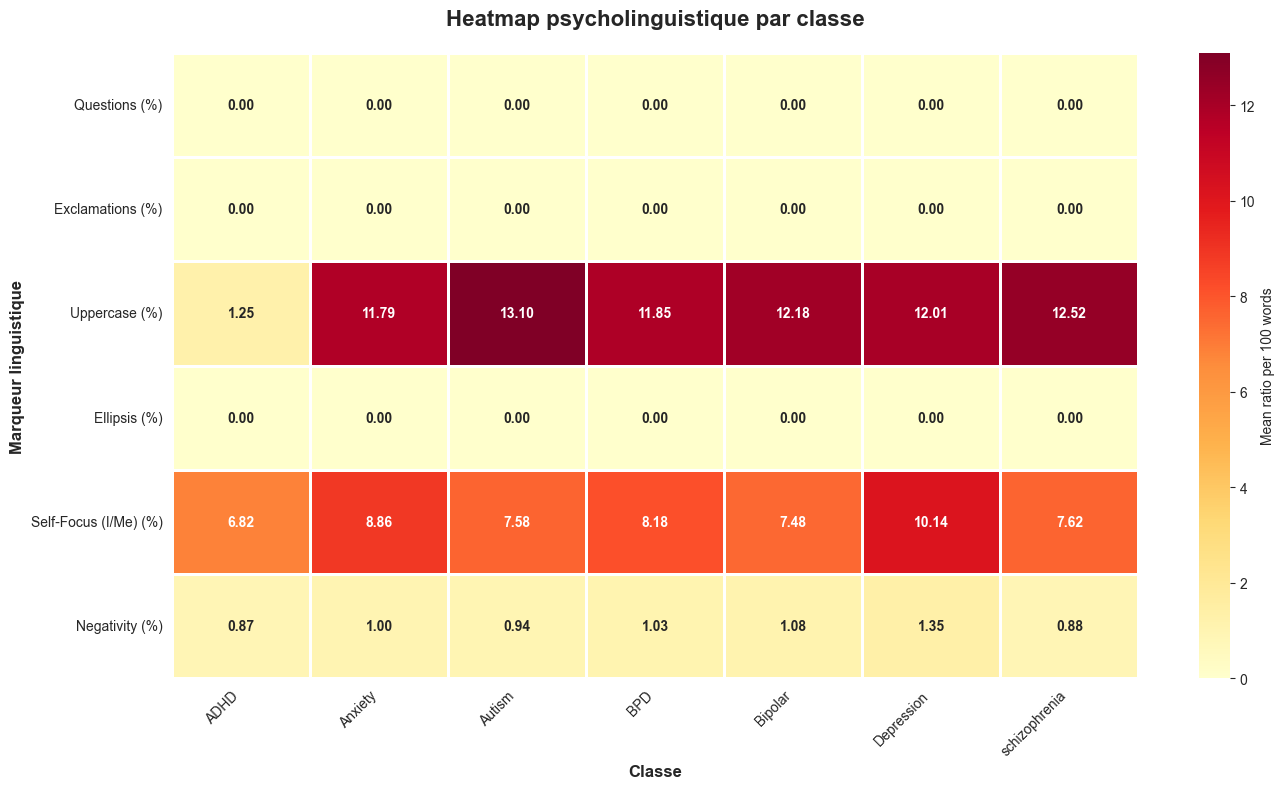

✅ Figure saved to: C:\Users\anafi\Desktop\final_project_jedha\reports\figures\eda\psycholinguistic_heatmap.png


In [25]:
# --- 1.4.4 Final Heatmap Visualization ---

plt.figure(figsize=(14, 8))

sns.heatmap(
    linguistic_stats.T,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=1.0,
    cbar_kws={"label": "Mean ratio per 100 words"},
    annot_kws={"size": 10, "weight": "bold"},
)

plt.title(
    "Heatmap psycholinguistique par classe",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Classe", fontsize=12, fontweight="bold")
plt.ylabel("Marqueur linguistique", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

heatmap_path = EDA_FIGURES_DIR / "psycholinguistic_heatmap.png"
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Figure saved to: {heatmap_path}")

### Synthèse intermédiaire — signatures psycholinguistiques

Les indicateurs calculés ci-dessus permettent d’identifier des différences de style d’écriture entre classes, sans pour autant constituer des preuves cliniques autonomes.

Ils sont utiles pour :
- comprendre ce que les modèles peuvent capter,
- repérer d’éventuels raccourcis non souhaités,
- enrichir l’interprétation qualitative du corpus.

<a id="1-5"></a>

## Audit de fuite lexicale

Cette section vise à identifier les termes explicites de diagnostic ou de médication susceptibles d’introduire une fuite d’information dans les futurs modèles.

In [26]:
# --- 1.5.1 Data Leakage Audit (Diagnosis & Medications) ---

# Safer audit list for reporting:
# remove ambiguous terms that may create false positives in normal language
AUDIT_LEAK_LIST = [term for term in FULL_LEAK_LIST if term.lower() not in {"add"}]

leak_detection = {}
for term in AUDIT_LEAK_LIST:
    pattern = rf"(?<!\w){re.escape(term)}(?!\w)"
    row_count = df[TEXT_COL].astype(str).str.contains(
        pattern,
        case=False,
        na=False,
        regex=True,
    ).sum()
    leak_detection[term] = row_count

combined_pattern = rf"(?<!\w)({'|'.join(re.escape(t) for t in AUDIT_LEAK_LIST)})(?!\w)"
rows_with_leak = df[TEXT_COL].astype(str).str.contains(
    combined_pattern,
    case=False,
    na=False,
    regex=True,
).sum()

total_pct_leak = round(rows_with_leak / len(df) * 100, 2) if len(df) else 0

leak_df = pd.DataFrame.from_dict(
    leak_detection,
    orient="index",
    columns=["Rows Containing Term"],
).sort_values("Rows Containing Term", ascending=False)

leak_df["Frequency (%)"] = (leak_df["Rows Containing Term"] / len(df) * 100).round(2)
leak_report = leak_df[leak_df["Rows Containing Term"] > 0].copy()
leak_report.index.name = "Clinical / Drug Term"

display(
    style_clinical_report(
        leak_report.style,
        title=f"Audit de fuite lexicale — {total_pct_leak}% des textes affectés",
        focus_classes=("bipolar", "schizophrenia", "lithium", "clozapine"),
        precision=2,
    )
)

leak_report.to_csv(EDA_TABLES_DIR / "leakage_audit_report.csv")

print(f"✅ Rows with lexical leakage: {rows_with_leak:,}")
print(f"✅ Leakage rate: {total_pct_leak:.2f}%")
print("⚠️ Ambiguous term excluded from audit: 'add'")

,Rows Containing Term,Frequency (%)
Clinical / Drug Term,,
anxiety,1945,17.26
adhd,1459,12.94
depression,1193,10.58
bpd,890,7.90
bipolar,758,6.73
depressed,682,6.05
anxious,674,5.98
autistic,506,4.49
autism,425,3.77


✅ Rows with lexical leakage: 6,453
✅ Leakage rate: 57.25%
⚠️ Ambiguous term excluded from audit: 'add'


In [27]:
# --- 1.5.2 Example Rows with Possible Leakage ---

leak_example_mask = df[TEXT_COL].astype(str).str.contains(
    combined_pattern,
    case=False,
    na=False,
    regex=True,
)

leak_examples = df.loc[leak_example_mask, [TEXT_COL, TARGET_COL]].copy()

print(f"Rows flagged for leakage review: {len(leak_examples):,}")

sample_n = min(20, len(leak_examples))
display(leak_examples.sample(sample_n, random_state=RANDOM_STATE) if sample_n > 0 else leak_examples.head())

leak_examples.head(100).to_csv(EDA_TABLES_DIR / "leakage_example_rows.csv", index=False)
print("✅ Leakage example rows exported")

Rows flagged for leakage review: 6,453


,body,category
9844,So basically Id like to post this as its been playing on my mind a bit \n\nBasically I do volunteer work for events I have cerebral palsy and wal...,Anxiety
162,At the moment Im just finding it super hard struggling with getting to sleep amp anxiety before I get up for work in the morning and I wanted to ...,BPD
1861,basically the title i dont even know if im allowed into this sub lol ive only been diagnosed with bpd traits \n\nim on a very mild antidepressant ...,BPD
5294,I entered what I thought was my first relationship a while back Ive talked to girls in the past but never felt that spark that made me want to com...,BPD
10946,wasnt really planning on making this post because i feel ridiculous even feeling this way but the more i think about it and the closer my wedding ...,Anxiety
8244,Ive been noticing a rather frustrating recurring theme in my life It appears as so\n\nI find myself in a very serious relationship where I want to...,BPD
2523,does anyone here with adhd get tics ive had one in my right arm for a while years actually it just kinda twitchesjumpsjerks randomly just one smal...,ADHD
1557,Anyone here in my boat My pwBPD husband of 20ish years was diagnosed just recently after a slew of other diagnoses Most of my posts before were in...,BPD
6472,I spend most months of the year depressed and at least a few of those are severe Every year Time keeps going by and no matter what I do nothing is...,Depression
7556,Im 25 years old female and I have been unemployed for a while I finally got a job and I have a 4 hour shift tomorrow in a warehouse I had my induc...,Anxiety


✅ Leakage example rows exported


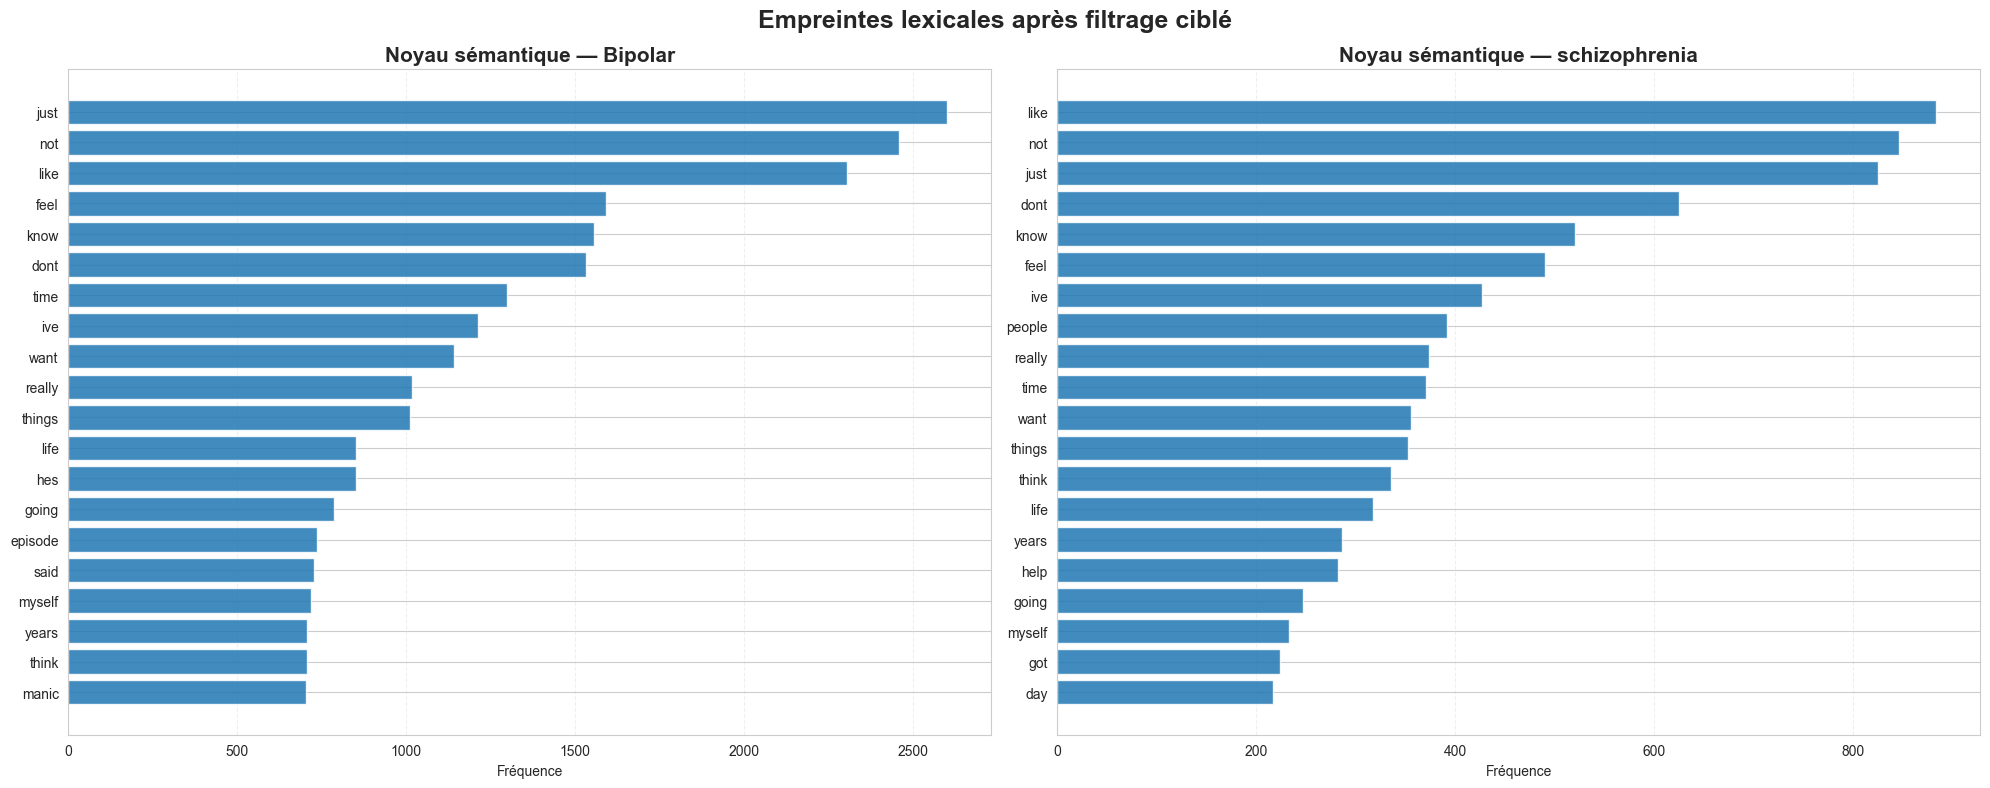

✅ Figure saved to: C:\Users\anafi\Desktop\final_project_jedha\reports\figures\eda\semantic_top_words.png


In [28]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# --- 1.6.1 Custom Stopword Strategy ---

base_stopwords = set(ENGLISH_STOP_WORDS)
clinical_signals = {"i", "me", "my", "myself", "mine", "no", "not", "never", "nothing"}
platform_noise = {"deleted", "removed", "edit", "update", "post", "sub", "reddit", "thanks"}

FINAL_STOPWORDS = (base_stopwords - clinical_signals).union(platform_noise)
FINAL_STOPWORDS.update([t.lower() for t in FULL_LEAK_LIST])

def extract_thematic_top_words(texts, n=20):
    all_words = []
    for text in texts:
        words = re.findall(r"\b[a-z]{3,}\b", str(text).lower())
        words = [w for w in words if w not in FINAL_STOPWORDS]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

sample_classes = ["Bipolar", "schizophrenia"]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for idx, cat in enumerate(sample_classes):
    subset_texts = df[df[TARGET_COL] == cat][TEXT_COL]
    top_words = extract_thematic_top_words(subset_texts, n=20)

    if not top_words:
        continue

    words, counts = zip(*top_words)

    axes[idx].barh(words, counts, alpha=0.85)
    axes[idx].invert_yaxis()
    axes[idx].set_title(f"Noyau sémantique — {cat}", fontsize=15, fontweight="bold")
    axes[idx].set_xlabel("Fréquence")
    axes[idx].grid(axis="x", linestyle="--", alpha=0.3)

plt.suptitle("Empreintes lexicales après filtrage ciblé", fontsize=18, fontweight="bold")
plt.tight_layout()

semantic_path = EDA_FIGURES_DIR / "semantic_top_words.png"
plt.savefig(semantic_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Figure saved to: {semantic_path}")

<a id="1-7"></a>

## Synthèse de l’EDA clinique

À l’issue de cette phase exploratoire, plusieurs constats méthodologiques ressortent :

- la structure du corpus est globalement exploitable pour la modélisation ;
- certaines différences de longueur et de style apparaissent entre classes, mais elles doivent être interprétées avec prudence ;
- une partie non négligeable des textes contient des termes explicitement liés à des diagnostics ou traitements, ce qui justifie un mécanisme de masquage ;
- cette fuite lexicale potentielle doit toutefois être auditée avec prudence, car certains termes peuvent être ambigus selon le contexte d’usage.

En conséquence, la suite du pipeline doit préserver deux objectifs :
1. nettoyer sans dégrader les signaux linguistiques utiles ;
2. réduire les raccourcis lexicaux trop explicites avant benchmark.

<a id="1-6"></a>

## Signatures sémantiques

Cette section explore les mots les plus fréquents après filtrage ciblé, afin d’obtenir une lecture plus qualitative du contenu thématique par classe.

In [29]:
# ============================================================
# PHASE 2 — PREPROCESSING & CLEANING
# Clinical-safe preprocessing:
# preserve punctuation, casing, pauses, repetitions,
# and psychologically relevant wording
# ============================================================

from html import unescape

required_cols = [TEXT_COL, TARGET_COL]
missing_cols = [col for col in required_cols if col not in df_raw.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in df_raw: {missing_cols}")

# Reuse the same canonical mapping defined earlier
if "CANONICAL_LABELS" not in globals():
    CANONICAL_LABELS = {
        "adhd": "ADHD",
        "add": "ADHD",
        "anxiety": "Anxiety",
        "autism": "Autism",
        "asd": "Autism",
        "autistic": "Autism",
        "bipolar": "Bipolar",
        "bpd": "BPD",
        "borderline": "BPD",
        "depression": "Depression",
        "depressed": "Depression",
        "schizophrenia": "schizophrenia",
        "schizo": "schizophrenia",
        "schizoaffective": "schizophrenia",
    }

In [30]:
# ----------------------------
# 2.3 Clinical-safe text cleaner
# ----------------------------
def clean_clinical_text(text):
    """
    Minimal cleaning for psychiatric text:
    - keep punctuation
    - keep casing
    - keep repetitions
    - keep clinically relevant wording
    - only normalize HTML, invisible characters and whitespace artifacts
    """
    if pd.isna(text):
        return None

    text = str(text)
    text = unescape(text)

    replacements = {
        "\xa0": " ",
        "\u200b": "",
        "\ufeff": "",
        "\r": "\n",
        "\t": " ",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    text = "\n".join(" ".join(line.split()) for line in text.split("\n")).strip()

    return text if text else None

In [31]:
# ----------------------------
# 2.4 Target normalizer
# ----------------------------
def normalize_target_label(label):
    if pd.isna(label):
        return None

    label = str(label).strip()
    if not label:
        return None

    return CANONICAL_LABELS.get(label.lower(), None)

In [32]:
# ----------------------------
# 2.5 Leakage helpers
# ----------------------------
def build_leakage_pattern(term_list):
    escaped_terms = [re.escape(term) for term in term_list]
    return rf"(?<!\w)({'|'.join(escaped_terms)})(?!\w)"

# Safer list for masking
MASKING_LEAK_LIST = [term for term in FULL_LEAK_LIST if term.lower() not in {"add"}]

LEAKAGE_PATTERN = build_leakage_pattern(MASKING_LEAK_LIST)

def mask_leakage_terms(text):
    if pd.isna(text):
        return None

    text = str(text)
    return re.sub(LEAKAGE_PATTERN, "[CONDITION]", text, flags=re.IGNORECASE)

In [33]:
# ----------------------------
# 2.7 Lightweight clinical features
# ----------------------------
initial_count = len(df_raw)

df = df_raw.copy()

df[TEXT_COL] = df[TEXT_COL].apply(clean_clinical_text)
df[TARGET_COL] = df[TARGET_COL].apply(normalize_target_label)

df = df.dropna(subset=[TEXT_COL, TARGET_COL]).copy()

df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip()

df = df[
    df[TEXT_COL].ne("") &
    df[TARGET_COL].ne("")
].copy()

if df.empty:
    raise ValueError("All rows were removed during preprocessing. Check df_raw integrity.")

df["text_len_chars"] = df[TEXT_COL].str.len()
df["text_len_words"] = df[TEXT_COL].str.split().str.len()

df["avg_word_len"] = df[TEXT_COL].apply(
    lambda x: round(np.mean([len(word) for word in str(x).split()]), 2)
    if str(x).split() else 0
)

df["has_possible_leakage"] = df[TEXT_COL].str.contains(LEAKAGE_PATTERN, na=False, regex=True)
df[MASKED_COL] = df[TEXT_COL].apply(mask_leakage_terms)

final_count = len(df)
removed_count = initial_count - final_count
retention_rate = (final_count / initial_count * 100) if initial_count else 0
leakage_rows = int(df["has_possible_leakage"].sum())
leakage_rate = (leakage_rows / len(df) * 100) if len(df) else 0

preprocessing_report = pd.DataFrame({
    "Clinical Metric": [
        "Initial Records",
        "Excluded (Missing/Empty/Unmapped)",
        "Retained Records",
        "Data Retention Rate",
        "Rows with Possible Leakage",
        "Leakage Rate",
    ],
    "Value": [
        f"{initial_count:,}",
        f"{removed_count:,}",
        f"{final_count:,}",
        f"{retention_rate:.2f}%",
        f"{leakage_rows:,}",
        f"{leakage_rate:.2f}%",
    ],
}).set_index("Clinical Metric")

display(
    style_clinical_report(
        preprocessing_report.style,
        title="Rapport de prétraitement final",
        focus_classes=[],
        precision=2,
    )
)

preprocessing_report.to_csv(EDA_TABLES_DIR / "final_preprocessing_report.csv")

print("✅ Phase 2 preprocessing completed successfully")
print(f"df_raw shape: {df_raw.shape}")
print(f"df shape: {df.shape}")
print(f"Target classes: {sorted(df[TARGET_COL].unique())}")

,Value
Clinical Metric,
Initial Records,"11,349"
Excluded (Missing/Empty/Unmapped),78
Retained Records,"11,271"
Data Retention Rate,99.31%
Rows with Possible Leakage,"5,710"
Leakage Rate,50.66%


✅ Phase 2 preprocessing completed successfully
df_raw shape: (11349, 2)
df shape: (11271, 7)
Target classes: ['ADHD', 'Anxiety', 'Autism', 'BPD', 'Bipolar', 'Depression', 'schizophrenia']


In [34]:
# ============================================================
# PHASE 2 — CLEANING VALIDATION CHECKS
# ============================================================

print("=" * 70)
print("CLEANING VALIDATION REPORT")
print("=" * 70)

required_objects = ["df_raw", "df", "TEXT_COL", "TARGET_COL", "MASKED_COL"]
missing_objects = [obj for obj in required_objects if obj not in globals()]
if missing_objects:
    raise ValueError(f"Missing required objects before validation: {missing_objects}")

for col in [TEXT_COL, TARGET_COL, MASKED_COL]:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in df")

validation_summary = pd.DataFrame({
    "Check": [
        "Raw rows",
        "Clean rows",
        "Rows removed",
        "Missing texts in clean df",
        "Missing targets in clean df",
        "Blank texts in clean df",
        "Blank targets in clean df",
        "Masked column missing values",
    ],
    "Value": [
        len(df_raw),
        len(df),
        len(df_raw) - len(df),
        int(df[TEXT_COL].isna().sum()),
        int(df[TARGET_COL].isna().sum()),
        int(df[TEXT_COL].astype(str).str.strip().eq("").sum()),
        int(df[TARGET_COL].astype(str).str.strip().eq("").sum()),
        int(df[MASKED_COL].isna().sum()),
    ]
})

display(validation_summary)

if df[TEXT_COL].isna().sum() > 0:
    raise ValueError("Missing values still present in text column.")
if df[TARGET_COL].isna().sum() > 0:
    raise ValueError("Missing values still present in target column.")
if df[TEXT_COL].astype(str).str.strip().eq("").sum() > 0:
    raise ValueError("Blank texts still present.")
if df[TARGET_COL].astype(str).str.strip().eq("").sum() > 0:
    raise ValueError("Blank targets still present.")

print("✅ Validation checks passed")

CLEANING VALIDATION REPORT


,Check,Value
0,Raw rows,11349
1,Clean rows,11271
2,Rows removed,78
3,Missing texts in clean df,0
4,Missing targets in clean df,0
5,Blank texts in clean df,0
6,Blank targets in clean df,0
7,Masked column missing values,0


✅ Validation checks passed


In [35]:
common_index = df.index.intersection(df_raw.index)

diff_mask = (
    df_raw.loc[common_index, TEXT_COL].astype(str).fillna("")
    != df.loc[common_index, TEXT_COL].astype(str).fillna("")
)

changed_rows = pd.DataFrame({
    "raw": df_raw.loc[common_index, TEXT_COL].astype(str),
    "clean": df.loc[common_index, TEXT_COL].astype(str),
})[diff_mask]

print(f"Number of changed rows: {len(changed_rows)}")
display(changed_rows.head(10))

changed_rows.head(50).to_csv(EDA_TABLES_DIR / "changed_rows_audit.csv", index=False)
print("✅ Changed rows audit saved")

Number of changed rows: 6923


,raw,clean
0,I often find myself checking on old friends on Facebook and seeing them enjoy life together I miss them and feel sad that nobody has contacted me ...,I often find myself checking on old friends on Facebook and seeing them enjoy life together I miss them and feel sad that nobody has contacted me ...
1,this is not a post asking if i have add depression or anxiety this is a post asking about an upcoming assessment and what it will entail\n\nif it ...,this is not a post asking if i have add depression or anxiety this is a post asking about an upcoming assessment and what it will entail\n\nif it ...
2,i went to my gp the other day to pick a new prescription of adderall out of the blue a nurse hands me a piss cup and tells me to fill it up i was ...,i went to my gp the other day to pick a new prescription of adderall out of the blue a nurse hands me a piss cup and tells me to fill it up i was ...
3,im a morning person and always envied stories of people pulling allnighters and staying up into the wee hours to start their new business ideas \n...,im a morning person and always envied stories of people pulling allnighters and staying up into the wee hours to start their new business ideas\n\...
4,im preparing to be rediagnosed for adhd as im a senior in college i have struggled with it my entire life and have been diagnosed twice \n\n how...,im preparing to be rediagnosed for adhd as im a senior in college i have struggled with it my entire life and have been diagnosed twice\n\nhowever...
5,so i work for a package delivery company and i recently got offered a chance to be a driver well i applied a while ago but they just now got openi...,so i work for a package delivery company and i recently got offered a chance to be a driver well i applied a while ago but they just now got openi...
6,tldr get diagnosed and write really long posts too \nnbsp \n\nthis is my first post here and i first wanted to thank all of you on radhd \ni ...,tldr get diagnosed and write really long posts too\nnbsp\n\nthis is my first post here and i first wanted to thank all of you on radhd\ni have bee...
7,Figured Id open up with my personal story with this illness TW DelusionsHallucinationsSelf Harm\n\nThe Start \n Age 20 In Iraq Didnt sleep for t...,Figured Id open up with my personal story with this illness TW DelusionsHallucinationsSelf Harm\n\nThe Start\nAge 20 In Iraq Didnt sleep for three...
8,First off Im sorry if this is a lot to read\n\n Ive been diagnosed with schizophrenia when I was 25 and Im about to turn 29 now But Im an avid ...,First off Im sorry if this is a lot to read\n\nIve been diagnosed with schizophrenia when I was 25 and Im about to turn 29 now But Im an avid fan ...
9,Hey \nUnfortunately I had an episode It started because I was bored Im very efficient at my work and I usually can solve complex tasks in a shor...,Hey\nUnfortunately I had an episode It started because I was bored Im very efficient at my work and I usually can solve complex tasks in a short a...


✅ Changed rows audit saved


In [36]:
ellipsis_pattern = r"\.{2,}"

ellipsis_changes = changed_rows[
    changed_rows["raw"].str.contains(ellipsis_pattern, regex=True, na=False) |
    changed_rows["clean"].str.contains(ellipsis_pattern, regex=True, na=False)
]

print(f"Rows involving ellipsis changes: {len(ellipsis_changes)}")
display(ellipsis_changes.head(20))

ellipsis_changes.head(50).to_csv(EDA_TABLES_DIR / "ellipsis_changes_audit.csv", index=False)
print("✅ Ellipsis audit saved")

Rows involving ellipsis changes: 0


,raw,clean


✅ Ellipsis audit saved


In [37]:
# ============================================================
# AUDIT ONLY — DO NOT OVERWRITE MAIN df
# ============================================================

def preprocess_dataset(df_input: pd.DataFrame, text_col: str = "clean") -> pd.DataFrame:
    """
    Lightweight audit helper only.
    Does NOT modify the main training dataframe.
    """
    if df_input is None or df_input.empty:
        return pd.DataFrame(columns=df_input.columns if df_input is not None else [text_col])

    df_input = df_input.copy()

    if text_col not in df_input.columns:
        raise ValueError(f"Column '{text_col}' not found in input dataframe.")

    df_input = df_input.dropna(subset=[text_col]).copy()
    df_input[text_col] = (
        df_input[text_col]
        .astype(str)
        .str.replace("\\n", " ", regex=False)
        .str.replace(r"\n+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    return df_input

changed_rows_clean = preprocess_dataset(changed_rows, text_col="clean")
display(changed_rows_clean.head(10))

print("✅ Audit dataframe created")
print("✅ Main df was NOT modified")

,raw,clean
0,I often find myself checking on old friends on Facebook and seeing them enjoy life together I miss them and feel sad that nobody has contacted me ...,I often find myself checking on old friends on Facebook and seeing them enjoy life together I miss them and feel sad that nobody has contacted me ...
1,this is not a post asking if i have add depression or anxiety this is a post asking about an upcoming assessment and what it will entail\n\nif it ...,this is not a post asking if i have add depression or anxiety this is a post asking about an upcoming assessment and what it will entail if it hel...
2,i went to my gp the other day to pick a new prescription of adderall out of the blue a nurse hands me a piss cup and tells me to fill it up i was ...,i went to my gp the other day to pick a new prescription of adderall out of the blue a nurse hands me a piss cup and tells me to fill it up i was ...
3,im a morning person and always envied stories of people pulling allnighters and staying up into the wee hours to start their new business ideas \n...,im a morning person and always envied stories of people pulling allnighters and staying up into the wee hours to start their new business ideas bu...
4,im preparing to be rediagnosed for adhd as im a senior in college i have struggled with it my entire life and have been diagnosed twice \n\n how...,im preparing to be rediagnosed for adhd as im a senior in college i have struggled with it my entire life and have been diagnosed twice however tw...
5,so i work for a package delivery company and i recently got offered a chance to be a driver well i applied a while ago but they just now got openi...,so i work for a package delivery company and i recently got offered a chance to be a driver well i applied a while ago but they just now got openi...
6,tldr get diagnosed and write really long posts too \nnbsp \n\nthis is my first post here and i first wanted to thank all of you on radhd \ni ...,tldr get diagnosed and write really long posts too nbsp this is my first post here and i first wanted to thank all of you on radhd i have been a l...
7,Figured Id open up with my personal story with this illness TW DelusionsHallucinationsSelf Harm\n\nThe Start \n Age 20 In Iraq Didnt sleep for t...,Figured Id open up with my personal story with this illness TW DelusionsHallucinationsSelf Harm The Start Age 20 In Iraq Didnt sleep for three day...
8,First off Im sorry if this is a lot to read\n\n Ive been diagnosed with schizophrenia when I was 25 and Im about to turn 29 now But Im an avid ...,First off Im sorry if this is a lot to read Ive been diagnosed with schizophrenia when I was 25 and Im about to turn 29 now But Im an avid fan of ...
9,Hey \nUnfortunately I had an episode It started because I was bored Im very efficient at my work and I usually can solve complex tasks in a shor...,Hey Unfortunately I had an episode It started because I was bored Im very efficient at my work and I usually can solve complex tasks in a short am...


✅ Audit dataframe created
✅ Main df was NOT modified


In [38]:
# ============================================================
# SAFETY CHECK — FINAL SANITY CHECK ON MAIN df
# ============================================================

required_cols = [TEXT_COL, TARGET_COL, MASKED_COL]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in df: {missing_cols}")

df = df.dropna(subset=[TEXT_COL, TARGET_COL, MASKED_COL]).copy()

df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip()
df[MASKED_COL] = df[MASKED_COL].astype(str).str.strip()

df = df[
    df[TEXT_COL].ne("") &
    df[TARGET_COL].ne("") &
    df[MASKED_COL].ne("")
].copy()

if df.empty:
    raise ValueError("df is empty after safety checks.")

print("✅ Final sanity check completed")
print("df shape:", df.shape)
display(df[[TEXT_COL, MASKED_COL, TARGET_COL]].head())

✅ Final sanity check completed
df shape: (11271, 7)


,body,body_masked,category
0,I often find myself checking on old friends on Facebook and seeing them enjoy life together I miss them and feel sad that nobody has contacted me ...,I often find myself checking on old friends on Facebook and seeing them enjoy life together I miss them and feel sad that nobody has contacted me ...,Depression
1,this is not a post asking if i have add depression or anxiety this is a post asking about an upcoming assessment and what it will entail\n\nif it ...,this is not a post asking if i have add [CONDITION] or [CONDITION] this is a post asking about an upcoming assessment and what it will entail\n\ni...,ADHD
2,i went to my gp the other day to pick a new prescription of adderall out of the blue a nurse hands me a piss cup and tells me to fill it up i was ...,i went to my gp the other day to pick a new prescription of [CONDITION] out of the blue a nurse hands me a piss cup and tells me to fill it up i w...,ADHD
3,im a morning person and always envied stories of people pulling allnighters and staying up into the wee hours to start their new business ideas\n\...,im a morning person and always envied stories of people pulling allnighters and staying up into the wee hours to start their new business ideas\n\...,ADHD
4,im preparing to be rediagnosed for adhd as im a senior in college i have struggled with it my entire life and have been diagnosed twice\n\nhowever...,im preparing to be rediagnosed for [CONDITION] as im a senior in college i have struggled with it my entire life and have been diagnosed twice\n\n...,ADHD


In [39]:
# ============================================================
# SAVE CLEAN DATASET SAFELY
# ============================================================

required_save_cols = [TEXT_COL, MASKED_COL, TARGET_COL]
missing_save_cols = [col for col in required_save_cols if col not in df.columns]

if missing_save_cols:
    raise ValueError(f"Missing columns before saving: {missing_save_cols}")

df_to_save = df[[TEXT_COL, MASKED_COL, TARGET_COL]].copy()
df_to_save.columns = ["body", "body_masked", "category"]

if df_to_save.empty:
    raise ValueError("Nothing to save: df_to_save is empty.")

df_to_save.to_csv(CLEAN_DATA_PATH, index=False)

export_summary = pd.DataFrame({
    "Metric": [
        "Export path",
        "Saved rows",
        "Saved columns",
        "Columns",
    ],
    "Value": [
        str(CLEAN_DATA_PATH),
        df_to_save.shape[0],
        df_to_save.shape[1],
        ", ".join(df_to_save.columns.tolist()),
    ],
})

display(export_summary)

print(f"✅ Clean dataset saved to: {CLEAN_DATA_PATH}")
print("Saved shape:", df_to_save.shape)
display(df_to_save.head())
print(df_to_save.isna().sum())

,Metric,Value
0,Export path,C:\Users\anafi\Desktop\final_project_jedha\data\clean\mental_health_detection_clean.csv
1,Saved rows,11271
2,Saved columns,3
3,Columns,"body, body_masked, category"


✅ Clean dataset saved to: C:\Users\anafi\Desktop\final_project_jedha\data\clean\mental_health_detection_clean.csv
Saved shape: (11271, 3)


,body,body_masked,category
0,I often find myself checking on old friends on Facebook and seeing them enjoy life together I miss them and feel sad that nobody has contacted me ...,I often find myself checking on old friends on Facebook and seeing them enjoy life together I miss them and feel sad that nobody has contacted me ...,Depression
1,this is not a post asking if i have add depression or anxiety this is a post asking about an upcoming assessment and what it will entail\n\nif it ...,this is not a post asking if i have add [CONDITION] or [CONDITION] this is a post asking about an upcoming assessment and what it will entail\n\ni...,ADHD
2,i went to my gp the other day to pick a new prescription of adderall out of the blue a nurse hands me a piss cup and tells me to fill it up i was ...,i went to my gp the other day to pick a new prescription of [CONDITION] out of the blue a nurse hands me a piss cup and tells me to fill it up i w...,ADHD
3,im a morning person and always envied stories of people pulling allnighters and staying up into the wee hours to start their new business ideas\n\...,im a morning person and always envied stories of people pulling allnighters and staying up into the wee hours to start their new business ideas\n\...,ADHD
4,im preparing to be rediagnosed for adhd as im a senior in college i have struggled with it my entire life and have been diagnosed twice\n\nhowever...,im preparing to be rediagnosed for [CONDITION] as im a senior in college i have struggled with it my entire life and have been diagnosed twice\n\n...,ADHD


body           0
body_masked    0
category       0
dtype: int64
